# Sale Price

<a target="_blank" href="https://colab.research.google.com/github/LuisAngelMendozaVelasco/luisangelmendozavelasco.github.io/blob/master/_portfolio/IBM_Introduction_to_Machine_Learning_Specialization/portfolio-4.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png">Run in Google Colab</a>

**Objective**: Train a Linear Regression model to predict the sale price of cars based on various features.

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")

## Load the dataset

In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/CarPrice_Assignment.csv"
df = pd.read_csv(file_url)
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## Understand the dataset

We will be using the car sales dataset, that can also be found and downloaded from [kaggle](https://www.kaggle.com/datasets/goyalshalini93/car-data?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01). The dataset contains all the information about cars, a name of a manufacturer, all car's technical parameters and a sale price of a car. We have 205 entries or rows, as well as 26 features. The **price** is our target, or response variable, and the rest of the features are our predictor variables.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

## Preprocess the dataset

In [4]:
df['brand'] = df["CarName"].str.split(' ').str.get(0).str.lower()
df['brand'] = df['brand'].replace(['vw', 'vokswagen'], 'volkswagen')
df['brand'] = df['brand'].replace(['maxda'], 'mazda')
df['brand'] = df['brand'].replace(['porcshce'], 'porsche')
df['brand'] = df['brand'].replace(['toyouta'], 'toyota')
df.drop(columns=['car_ID', 'CarName'], inplace=True)

preprocessed_df = pd.get_dummies(df, drop_first=True)
preprocessed_df.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,brand_nissan,brand_peugeot,brand_plymouth,brand_porsche,brand_renault,brand_saab,brand_subaru,brand_toyota,brand_volkswagen,brand_volvo
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,False,False,False
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,False,False,False
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,False,False,False,False,False,False,False,False,False,False
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,False,False,False,False,False,False,False,False,False,False
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,False,False,False,False,False,False,False,False,False,False


## Visualize the dataset

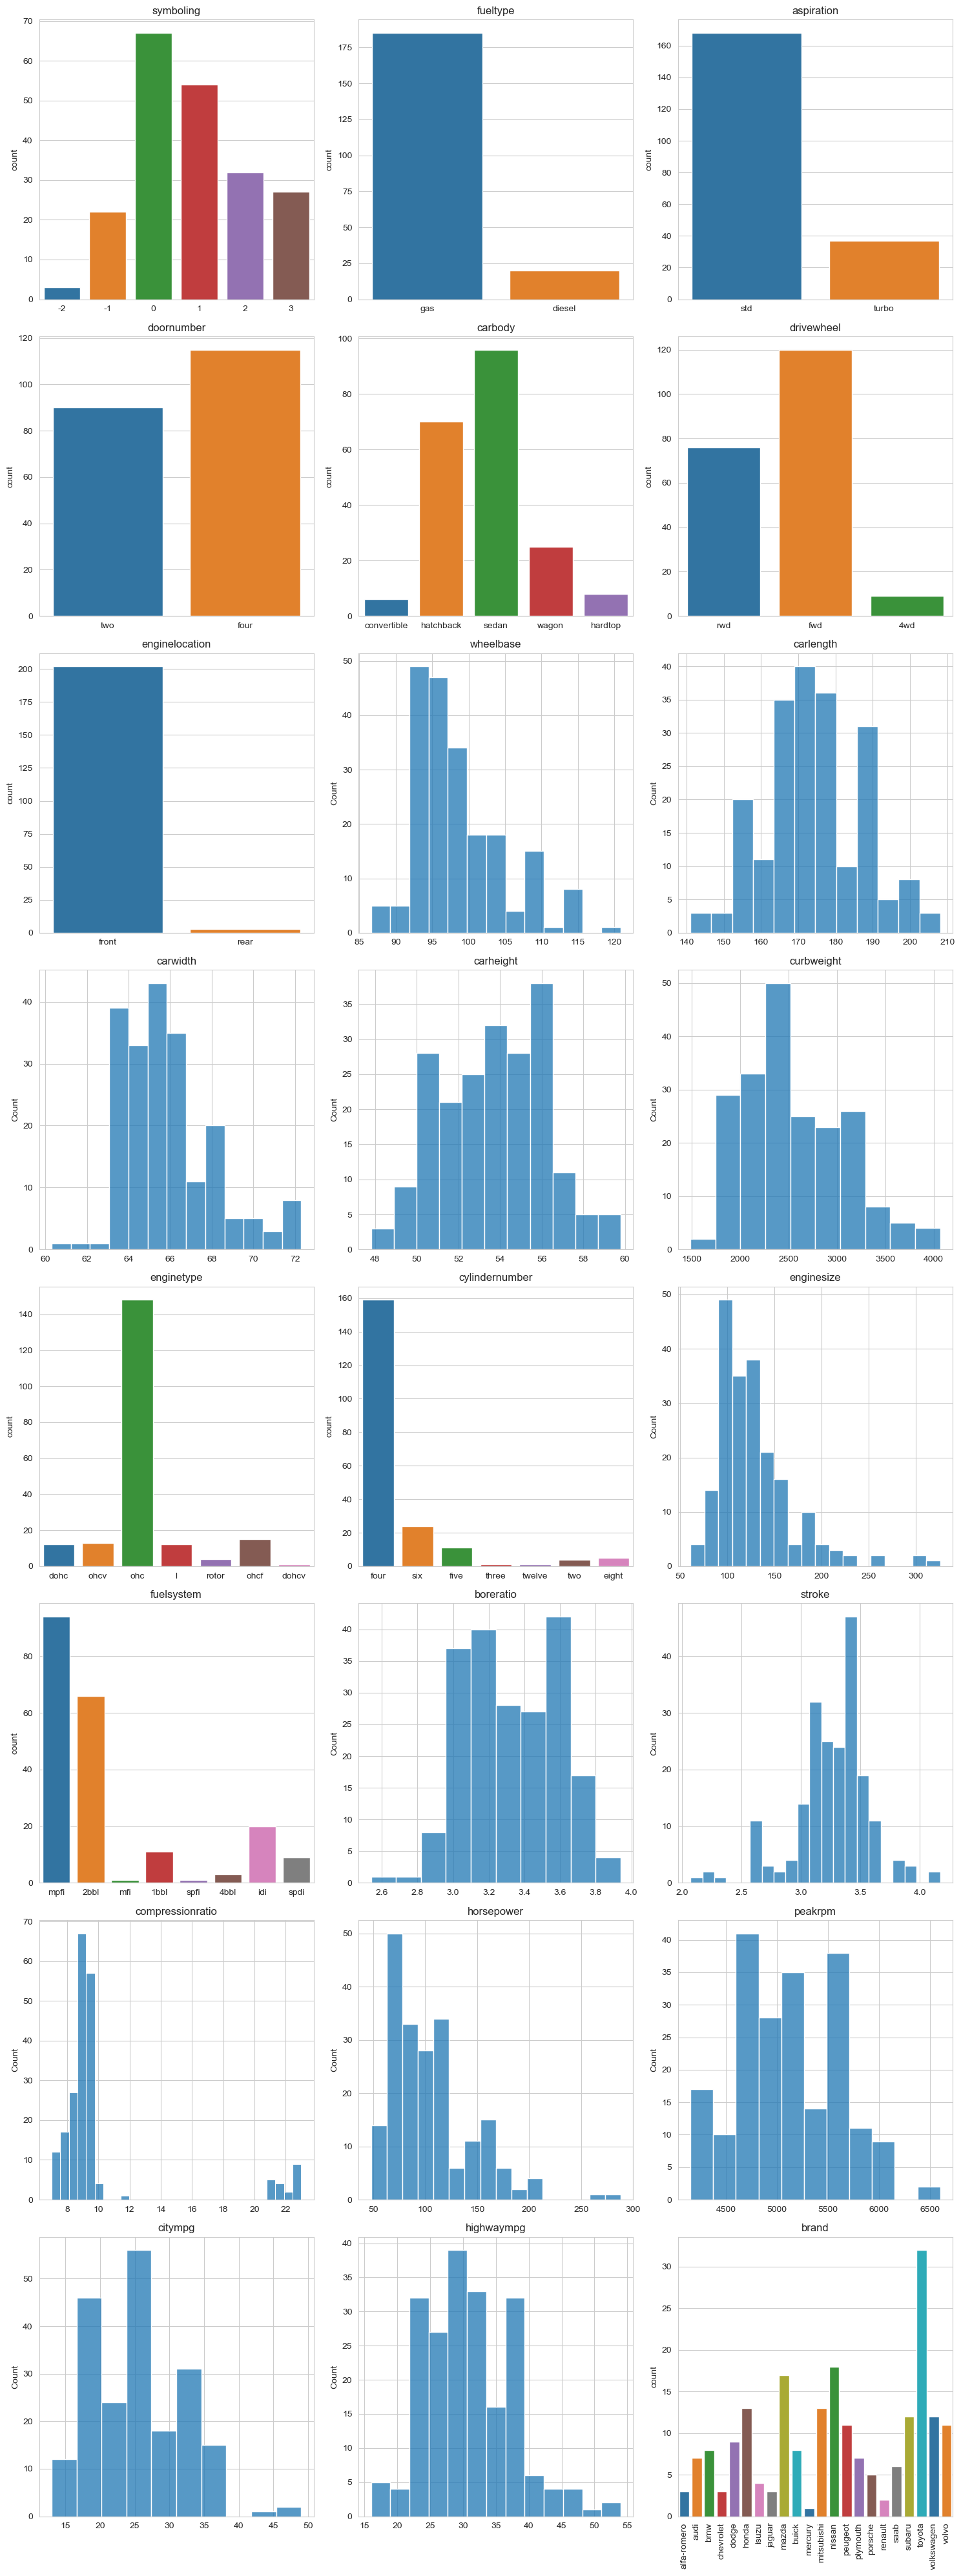

In [5]:
number_features = df.shape[1] - 1
grid_rows = int(np.ceil(number_features / 3))
fig, axs = plt.subplots(grid_rows, 3, figsize=(15, 5 * grid_rows))

for ax, feature in zip(axs.flatten(), df.drop(columns=["price"]).columns):
    if df[feature].dtype == 'O':
        sns.countplot(data=df, x=feature, ax=ax, hue=feature, palette="tab10")
        ax.set_xlabel("")
        ax.set_title(feature)
        if feature == 'brand':
            unique_values = df[feature].unique()
            ax.set_xticks(range(len(unique_values)), rotation='vertical', labels=unique_values)
    elif len(df[feature].unique()) <= 10:
        sns.countplot(data=df, x=feature, ax=ax, hue=feature, palette="tab10", legend=False)
        ax.set_xlabel("")
        ax.set_title(feature)
    else:
        sns.histplot(data=df, x=feature, ax=ax)
        ax.set_xlabel("")
        ax.set_title(feature)

plt.tight_layout()
plt.show()

## Visualize the target feature

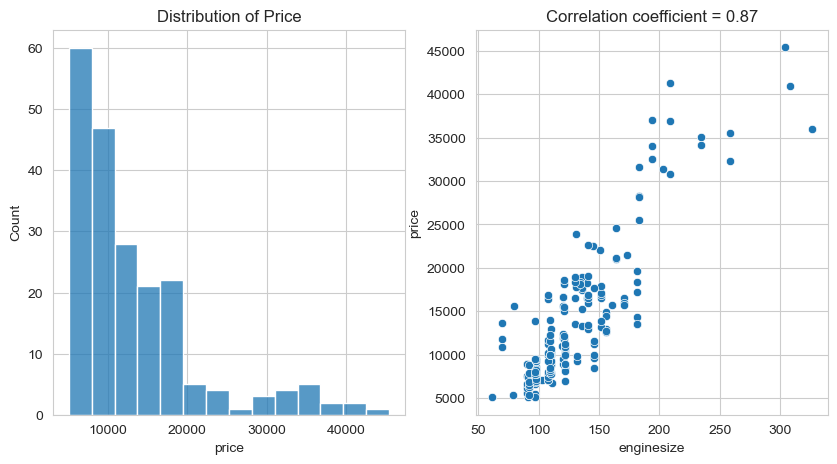

In [6]:
target_feature = "price"
correlations = {}

for feature in df.drop(columns=[target_feature]).columns:
    if df[feature].dtype != 'O':
        correlations[feature] = stats.pearsonr(df[feature], df[target_feature])[0]

max_correlation_feature = max(correlations, key=lambda key: abs(correlations[key]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.histplot(x=target_feature, data=df, ax=ax1)
ax1.set_title("Distribution of Price")

sns.scatterplot(x=df[max_correlation_feature], y=df[target_feature], ax=ax2)
ax2.set_title(f"Correlation coefficient = {correlations[max_correlation_feature]:.2f}")

plt.show()

## Split the dataset into train and test subsets

In [7]:
X = preprocessed_df.drop(columns=[target_feature])
y = preprocessed_df[target_feature]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (153, 64)
X_test shape: (52, 64)


## Train a Linear Regression model

In [8]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Evaluate the Linear Regression model

In [9]:
y_pred = regressor.predict(X_test)

print(f"MSE = {mean_squared_error(y_test, y_pred):.2f}")
print(f"R² = {r2_score(y_test, y_pred):.2f}")

MSE = 9127400.65
R² = 0.88


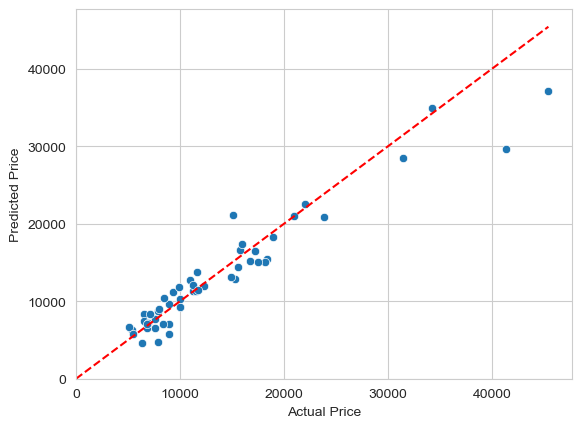

In [10]:
plt.figure()
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([0, y_test.max()], [0, y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.xlim(0, y_test.max()*1.05)
plt.ylim(0, y_test.max()*1.05)
plt.show()